# Vorlage Plausi-Tests

### Kurzbeschreibung
Zusammengefasste Geburtenziffer: Zusammengefasste Geburtenziffer nach Herkunft und Jahr seit 1993.

Datum: 19.02.2025


Dataset auf PROD-Datakatalog: Link 

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_zgz_jahr_herkunft_od4118


### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [3]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [4]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [5]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [6]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
#pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [7]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [8]:
package_name = "bev_zgz_jahr_herkunft_od4118"

In [9]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV411OD4118"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_zgz_jahr_herkunft_od4118/download/BEV411OD4118.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_zgz_jahr_herkunft_od4118 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_zgz_jahr_herkunft_od4118 

data_source: web


In [10]:
data2betested.head(2).T

,0,1
StichtagDatJahr,1993-01-01 00:00:00,1993-01-01 00:00:00
HerkunftMutterCd,0,1
HerkunftMutterLang,Total,Schweizerinnen
ZGZ_noDM,1.13,0.92


Berechne weitere Attribute falls notwendig

In [11]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
HerkunftMutterCd                int64
HerkunftMutterLang             object
ZGZ_noDM                      float64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [12]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2024


In [13]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993-12-31 und ein Maximumjahr von 2024-12-31


### Einfache Datentests

In [14]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 96 entries, 95 to 0
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      96 non-null     datetime64[ns]
 1   HerkunftMutterCd     96 non-null     int64         
 2   HerkunftMutterLang   96 non-null     object        
 3   ZGZ_noDM             96 non-null     float64       
 4   StichtagDatJahr_str  96 non-null     object        
 5   Jahr                 96 non-null     datetime64[ns]
 6   Jahr_end             96 non-null     datetime64[ns]
 7   Jahr_nbr             96 non-null     int32         
dtypes: datetime64[ns](3), float64(1), int32(1), int64(1), object(2)
memory usage: 18.3 KB


In [15]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 96 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [16]:
data2betested.describe()

,StichtagDatJahr,HerkunftMutterCd,ZGZ_noDM,Jahr,Jahr_end,Jahr_nbr
count,96,96.000000,96.000000,96,96,96.000000
mean,2008-07-02 00:00:00,1.000000,1.258750,2008-07-02 00:00:00,2009-07-01 06:00:00,2008.500000
min,1993-01-01 00:00:00,0.000000,0.800000,1993-01-01 00:00:00,1993-12-31 00:00:00,1993.000000
25%,2000-10-01 12:00:00,0.000000,1.120000,2000-10-01 12:00:00,2001-09-30 18:00:00,2000.750000
50%,2008-07-02 00:00:00,1.000000,1.210000,2008-07-02 00:00:00,2009-07-01 12:00:00,2008.500000
75%,2016-04-01 12:00:00,2.000000,1.490000,2016-04-01 12:00:00,2017-04-01 06:00:00,2016.250000
max,2024-01-01 00:00:00,2.000000,1.840000,2024-01-01 00:00:00,2024-12-31 00:00:00,2024.000000
std,NaN,0.820783,0.261346,NaN,NaN,9.281561


Welches sind die Datensätze ohne Werte bei ZGZ_noDM?

In [17]:
data2betested[np.isnan(data2betested.ZGZ_noDM)]

,StichtagDatJahr,HerkunftMutterCd,HerkunftMutterLang,ZGZ_noDM,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [18]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [19]:
data2betested.index.year.unique()

Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [20]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,HerkunftMutterLang,StichtagDatJahr_str,Jahr,Jahr_end
count,96,96,96,96
unique,3,32,NaN,NaN
top,Total,1993-01-01,NaN,NaN
freq,32,3,NaN,NaN
mean,NaN,NaN,2008-07-02 00:00:00,2009-07-01 06:00:00
min,NaN,NaN,1993-01-01 00:00:00,1993-12-31 00:00:00
25%,NaN,NaN,2000-10-01 12:00:00,2001-09-30 18:00:00
50%,NaN,NaN,2008-07-02 00:00:00,2009-07-01 12:00:00
75%,NaN,NaN,2016-04-01 12:00:00,2017-04-01 06:00:00
max,NaN,NaN,2024-01-01 00:00:00,2024-12-31 00:00:00


Beschreibe numerische Attribute

In [21]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,HerkunftMutterCd,ZGZ_noDM,Jahr_nbr
count,96,96,96
mean,1,1,"2,008"
std,1,0,9
min,0,1,"1,993"
25%,0,1,"2,001"
50%,1,1,"2,008"
75%,2,1,"2,016"
max,2,2,"2,024"


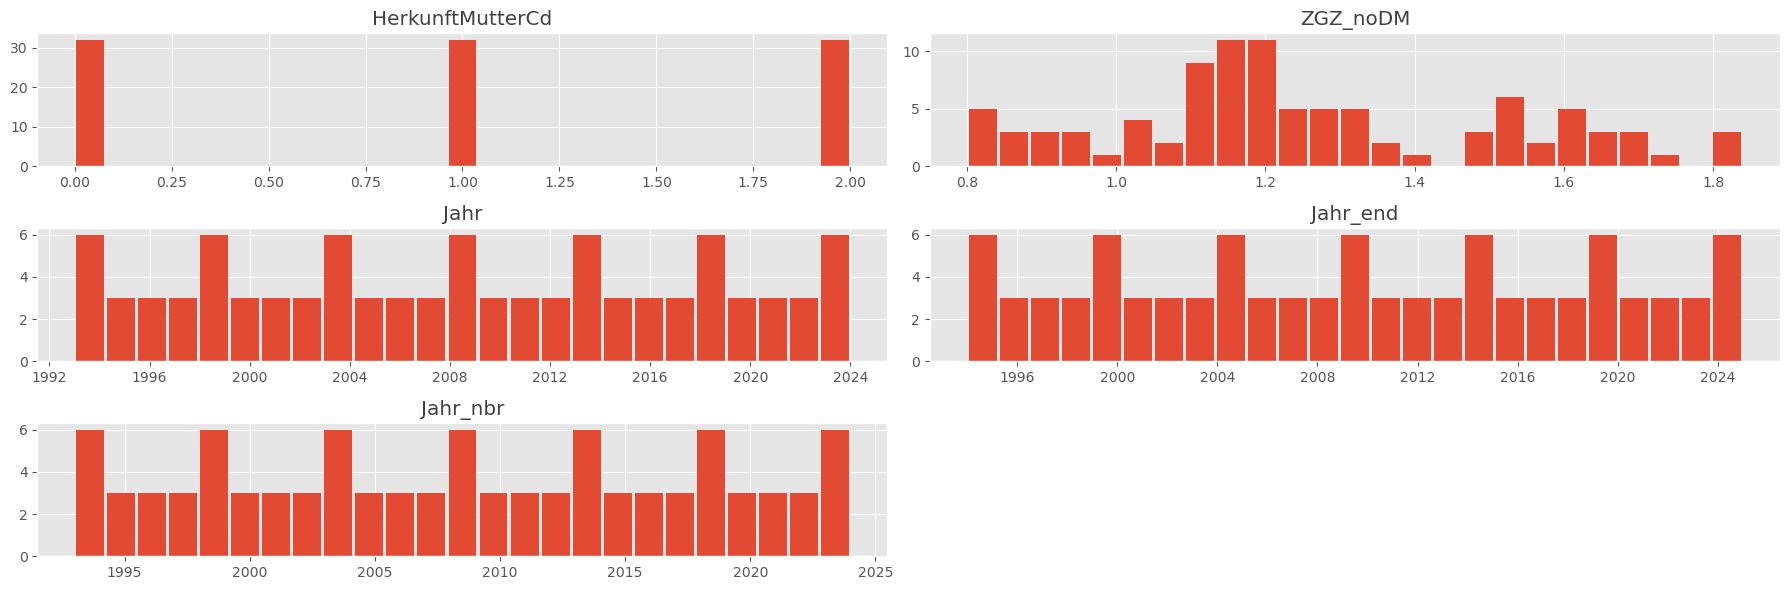

In [22]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [23]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,HerkunftMutterCd,HerkunftMutterLang,ZGZ_noDM,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,


### Nullwerte und Missings?

In [24]:
data2betested.isnull().sum()

HerkunftMutterCd       0
HerkunftMutterLang     0
ZGZ_noDM               0
StichtagDatJahr_str    0
Jahr                   0
Jahr_end               0
Jahr_nbr               0
dtype: int64

In [25]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [26]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(mean_ZGZ_noDM=('ZGZ_noDM', 'mean'), count_ZGZ_noDM=('ZGZ_noDM','count')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index()#.head(3)

,Jahr,Jahr_nbr,Jahr_end,mean_ZGZ_noDM,count_ZGZ_noDM
0,2024-01-01,2024,2024-12-31,1.026667,3
1,2023-01-01,2023,2023-12-31,1.053333,3
2,2022-01-01,2022,2022-12-31,1.070000,3
3,2021-01-01,2021,2021-12-31,1.260000,3
4,2020-01-01,2020,2020-12-31,1.236667,3
5,2019-01-01,2019,2019-12-31,1.243333,3
6,2018-01-01,2018,2018-12-31,1.296667,3
7,2017-01-01,2017,2017-12-31,1.316667,3
8,2016-01-01,2016,2016-12-31,1.330000,3
9,2015-01-01,2015,2015-12-31,1.363333,3


In [27]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftMutterCd', 'HerkunftMutterLang']) \
    .agg(mean_ZGZ_noDM=('ZGZ_noDM', 'mean'), count_ZGZ_noDM=('ZGZ_noDM','count')) \
    .sort_values('HerkunftMutterCd', ascending=False) 
agg_herk.reset_index()#.head(3)

,HerkunftMutterCd,HerkunftMutterLang,mean_ZGZ_noDM,count_ZGZ_noDM
0,2,Ausländerinnen,1.552258,31
1,1,Schweizerinnen,1.029355,31
2,0,Total,1.200968,31


In [28]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'HerkunftMutterCd', 'HerkunftMutterLang', 'ZGZ_noDM',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

### Visualisierungen nach Zeitausschnitten

#### Zeitreihe Zusammengefasste Geburtenziffer

In [29]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'ZGZ_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Zusammengefasste Geburtenziffer'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Zeitreihe Zusammengefasste Geburtenziffer, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1566&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7BCEAF2600%2D5498%2D413B%2D88AA%2DBEE20C2F4F2F%7D%23InplviewHashceaf2600%2D5498%2D413b%2D88aa%2Dbee20c2f4f2f%3D&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------